In [1]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.datasets import load_breast_cancer
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

In [2]:
# Load Breast Cancer data
cancer = load_breast_cancer()
X = cancer.data  # features only (unsupervised)
df = pd.DataFrame(X, columns=cancer.feature_names)

# Display first 5 rows
print(df.head())

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst radius  worst texture  worst perimeter  \
0           

In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [4]:
# Initialize metrics lists
inertia = []
silhouette_scores = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)

    # Store inertia (Within-Cluster Sum of Squares)
    inertia.append(kmeans.inertia_)

    # Silhouette score is only valid for k >= 2 clusters
    if k > 1:
        score = silhouette_score(X_scaled, labels)
        silhouette_scores.append(score)

In [5]:
# Print the evaluation profiles side by side
print("--- Cluster Evaluation Metrics ---")
for i, val in enumerate(inertia, start=1):
    if i == 1:
        print(f"Number of clusters = {i} | Inertia = {val:.2f} | Silhouette Score = N/A")
    else:
        score = silhouette_scores[i-2]
        print(f"Number of clusters = {i} | Inertia = {val:.2f} | Silhouette Score = {score:.4f}")

--- Cluster Evaluation Metrics ---
Number of clusters = 1 | Inertia = 17070.00 | Silhouette Score = N/A
Number of clusters = 2 | Inertia = 11595.68 | Silhouette Score = 0.3447
Number of clusters = 3 | Inertia = 10066.28 | Silhouette Score = 0.3152
Number of clusters = 4 | Inertia = 9266.15 | Silhouette Score = 0.2742
Number of clusters = 5 | Inertia = 9263.40 | Silhouette Score = 0.1645
Number of clusters = 6 | Inertia = 8562.88 | Silhouette Score = 0.1451
Number of clusters = 7 | Inertia = 8016.37 | Silhouette Score = 0.1470
Number of clusters = 8 | Inertia = 7288.48 | Silhouette Score = 0.1619
Number of clusters = 9 | Inertia = 7040.99 | Silhouette Score = 0.1439
Number of clusters = 10 | Inertia = 6668.85 | Silhouette Score = 0.1471


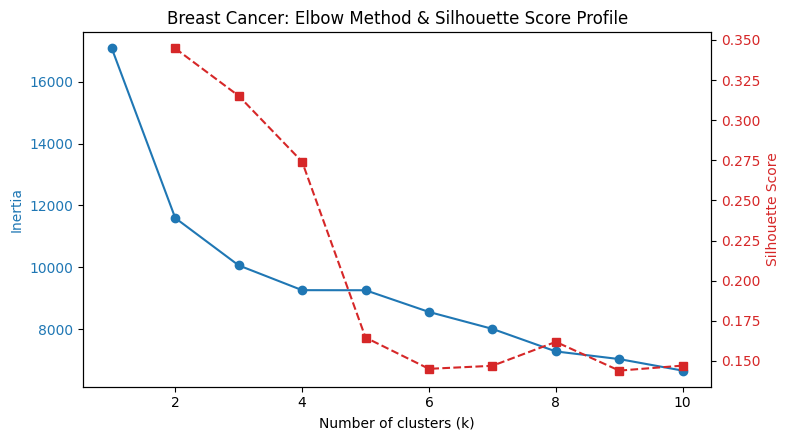

In [6]:
# Create a dual-axis evaluation plot
fig, ax1 = plt.subplots(figsize=(8, 4.5))

# Plot Inertia on primary y-axis (Left Side)
ax1.set_xlabel("Number of clusters (k)")
ax1.set_ylabel("Inertia", color="tab:blue")
ax1.plot(range(1, 11), inertia, marker="o", color="tab:blue", label="Inertia")
ax1.tick_params(axis="y", labelcolor="tab:blue")

# Plot Silhouette Score on secondary y-axis (Right Side)
ax2 = ax1.twinx()
ax2.set_ylabel("Silhouette Score", color="tab:red")
ax2.plot(range(2, 11), silhouette_scores, marker="s", color="tab:red", linestyle="--", label="Silhouette Score")
ax2.tick_params(axis="y", labelcolor="tab:red")

plt.title("Breast Cancer: Elbow Method & Silhouette Score Profile")
fig.tight_layout()
plt.show()

In [7]:
# K-Means with 2 clusters
kmeans = KMeans(n_clusters=2, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# Add cluster assignments to dataframe
df['Cluster'] = clusters
print(df.head())

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  worst area  \
0             

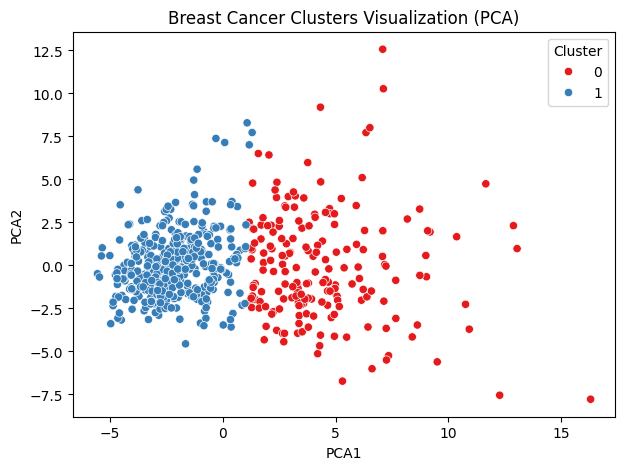

In [8]:
# Reduce the 30-dimensional data to 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df['PCA1'] = X_pca[:,0]
df['PCA2'] = X_pca[:,1]

# Plot clusters
plt.figure(figsize=(7,5))
sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster', data=df, palette='Set1')
plt.title("Breast Cancer Clusters Visualization (PCA)")
plt.show()